# V34: LQ45 Label Analysis - Bull vs Bear Distribution in Training Data

This notebook provides a detailed analysis of the **Classification Labels** used to train the AI. 
Understanding the balance between Bull (Market Uptrend) and Bear (Market Downtrend/Flat) is crucial for evaluating model bias.

### Labeling Logic (V33 Pattern):
- **Bull (1)**: The average return over the **next 3 trading days** is greater than a small threshold (0.0005).
- **Bear (0)**: Otherwise (Negative trend or stagnant market).

### Visualizations:
1. **Class Distribution**: Pie and Bar charts of the labels.
2. **Label Overlay on Market**: Visualizing where the Bull/Bear signals fall on the actual price history of the LQ45/IHSG proxy portfolio.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1) 
market_price = (1 + market_return).cumprod() * 100

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [2]:
# --- 2. Generate Labels (Training Data: 2023-2024) ---

train_price = market_price.loc[market_price.index.year <= 2024]
train_returns = market_return.loc[train_price.index]

# Logic from V33: 3-day future window trend
future_window = 3
trend_threshold = 0.0005
next_3d_mean = train_returns.rolling(window=future_window).mean().shift(-future_window)
labels = (next_3d_mean > trend_threshold).astype(int)

# Cleanup for plotting
analysis_df = pd.DataFrame({
    'Price': train_price,
    'Next_3d_Mean': next_3d_mean,
    'Label': labels
}).dropna()

label_map = {1: 'Bull (Uptrend)', 0: 'Bear/Flat'}
analysis_df['Label_Text'] = analysis_df['Label'].map(label_map)

print("Training Set Label Distribution:")
print(analysis_df['Label_Text'].value_counts())
print(f"Total Training Samples: {len(analysis_df)}")

Training Set Label Distribution:
Label_Text
Bull (Uptrend)    244
Bear/Flat         228
Name: count, dtype: int64
Total Training Samples: 472


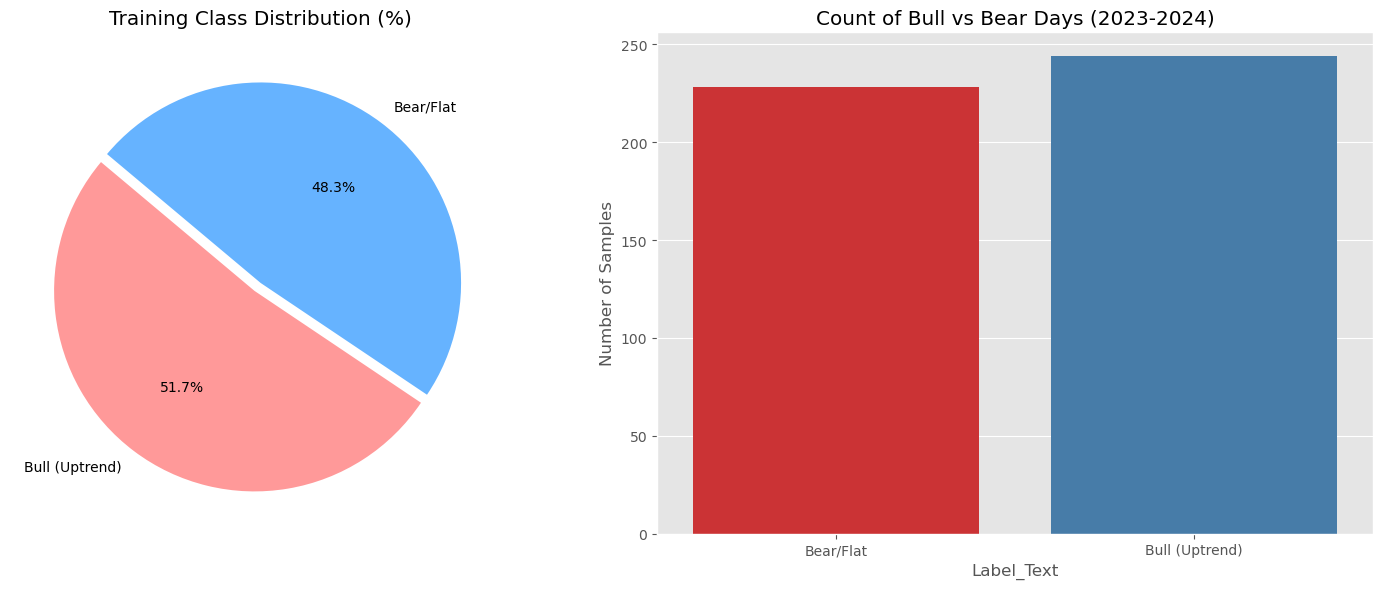

In [3]:
# --- 3. Visualization: Class Balance ---

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Pie Chart
counts = analysis_df['Label_Text'].value_counts()
ax[0].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=140, explode=(0.05, 0))
ax[0].set_title("Training Class Distribution (%)")

# Bar Chart
sns.countplot(data=analysis_df, x='Label_Text', palette='Set1', ax=ax[1])
ax[1].set_title("Count of Bull vs Bear Days (2023-2024)")
ax[1].set_ylabel("Number of Samples")

plt.tight_layout()
plt.savefig('v34_class_balance.png', dpi=300)
plt.show()

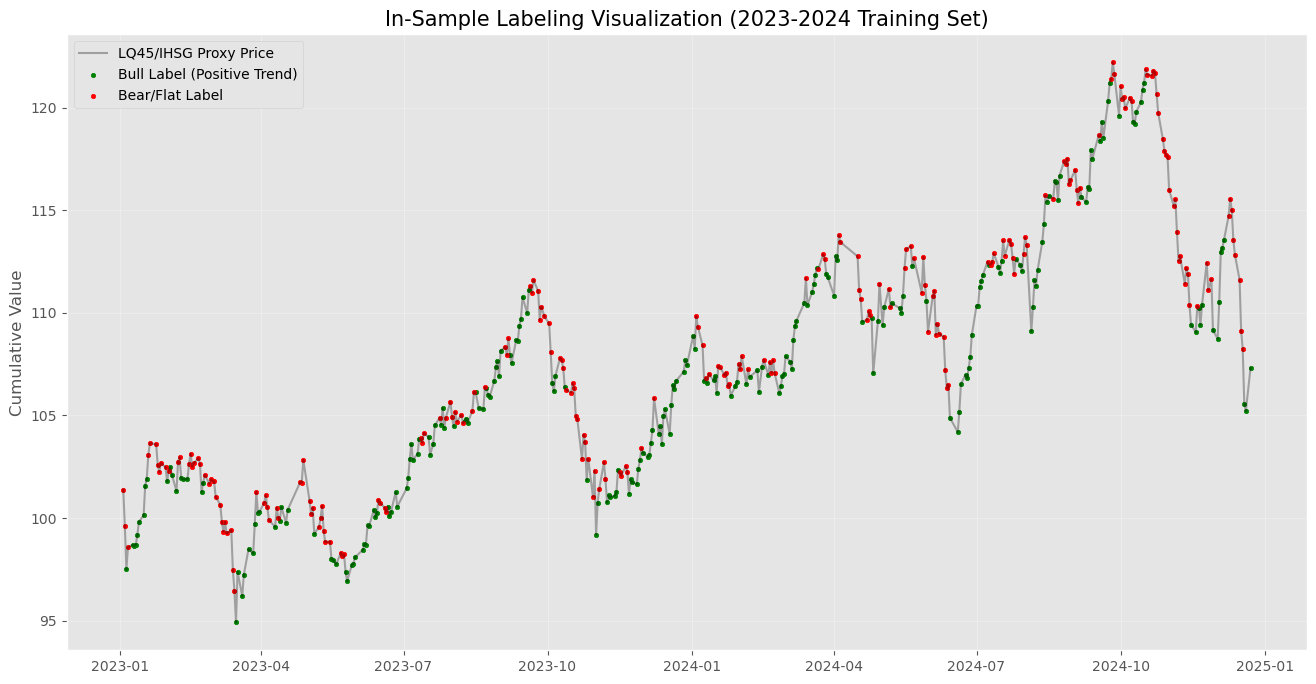

Interpretation:
The scatter plot shows how the 3-day trend labeling identifies regions of growth (green).
If there are significantly more Reds than Greens, the model is 'Conservative'.


In [4]:
# --- 4. Visualization: Label Overlay on Market Price ---

plt.figure(figsize=(16, 8))
plt.plot(analysis_df.index, analysis_df['Price'], color='black', alpha=0.3, label='LQ45/IHSG Proxy Price')

# Highlight Bullish days
bull_days = analysis_df[analysis_df['Label'] == 1]
plt.scatter(bull_days.index, bull_days['Price'], color='green', s=10, label='Bull Label (Positive Trend)')

# Highlight Bearish/Flat days
bear_days = analysis_df[analysis_df['Label'] == 0]
plt.scatter(bear_days.index, bear_days['Price'], color='red', s=10, label='Bear/Flat Label')

plt.title("In-Sample Labeling Visualization (2023-2024 Training Set)", fontsize=15)
plt.ylabel("Cumulative Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('v34_label_overlay.png', dpi=300)
plt.show()

print("Interpretation:")
print("The scatter plot shows how the 3-day trend labeling identifies regions of growth (green).")
print("If there are significantly more Reds than Greens, the model is 'Conservative'.")